## Imports

In [179]:
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression Models
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

## Read & Load the Dataset

In [180]:
# Load the dataset
df = pd.read_csv('melb_data.csv')

# Display the first 5 rows
df.head(100)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Albert Park,4a Gatehouse La,3,h,1370000.0,S,Greg,12/06/2016,3.3,3206.0,...,2.0,2.0,0.0,85.0,2000.0,Port Phillip,-37.8451,144.9511,Southern Metropolitan,3280.0
96,Albert Park,60 Brooke St,2,h,1000000.0,S,Cayzer,12/11/2016,3.3,3206.0,...,1.0,0.0,288.0,NaN,NaN,Port Phillip,-37.8407,144.9523,Southern Metropolitan,3280.0
97,Albert Park,70 Barrett St,3,h,2575000.0,S,Greg,15/10/2016,3.3,3206.0,...,2.0,1.0,228.0,NaN,NaN,Port Phillip,-37.8445,144.9501,Southern Metropolitan,3280.0
98,Albert Park,65 Graham St,2,h,1322500.0,S,Greg,15/10/2016,3.3,3206.0,...,1.0,0.0,149.0,98.0,1890.0,Port Phillip,-37.8443,144.9481,Southern Metropolitan,3280.0


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Filling Missing Values

##### Filling the nulls of car attribute with the Mode

In [182]:
df["Car"].fillna(df["Car"].mode()[0], inplace=True)

C:\Users\ziadr\AppData\Local\Temp\ipykernel_16880\2310188740.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Car"].fillna(df["Car"].mode()[0], inplace=True)


##### Filling the nulls of Building area attribute with the median of each group of rooms number ensuring that the building area does not exceed the land size

In [183]:
df["BuildingArea"] = df.groupby("Rooms")["BuildingArea"].transform(
    lambda x: x.fillna(x.median() if not pd.isna(x.median()) else df["BuildingArea"].median())
)

df.loc[df["BuildingArea"] > df["Landsize"], "BuildingArea"] = df["Landsize"]


C:\Users\ziadr\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


##### Filling the nulls of the year built attribute with the median of each suburb group

In [184]:
df["YearBuilt"] = df.groupby("Suburb")["YearBuilt"].transform(
    lambda x: x.fillna(x.median() if not pd.isna(x.median()) else df["YearBuilt"].median())
)

C:\Users\ziadr\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ziadr\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ziadr\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ziadr\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ziadr\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ziadr\AppData\Roaming\Pyth

##### Filling the nulls of the Council area attribute with the mode of each suburb group

In [185]:

df["CouncilArea"] = df.groupby("Suburb")["CouncilArea"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else df["CouncilArea"].mode()[0])
)

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13580 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   13580 non-null  float64
 15  YearBuilt      13580 non-null  float64
 16  CouncilArea    13580 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Data Visualization

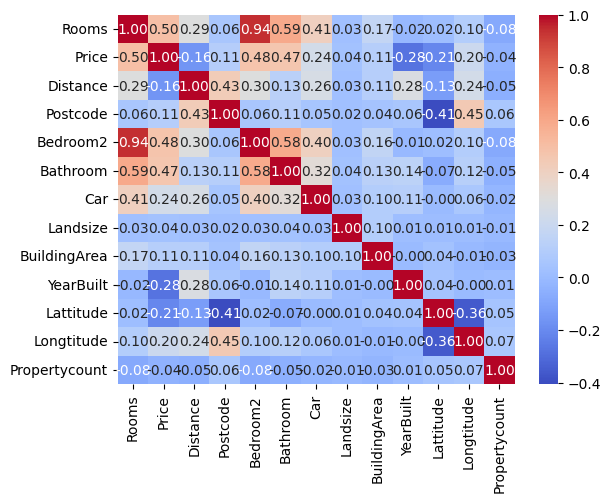

In [187]:
# Correlation Heatmap (Numerical Features Only)
numeric_df = df.select_dtypes(include=['number'])
categorical_df = df.select_dtypes(include=['object'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

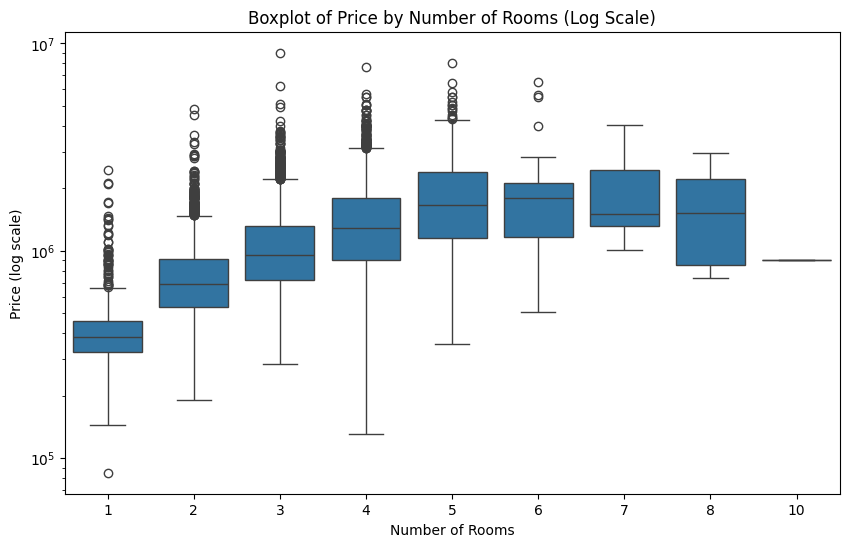

In [188]:
# Boxplot of Price by Number of Rooms
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rooms', y='Price', data=df)

plt.yscale('log') 

plt.title('Boxplot of Price by Number of Rooms (Log Scale)')
plt.xlabel('Number of Rooms')
plt.ylabel('Price (log scale)')
plt.show()

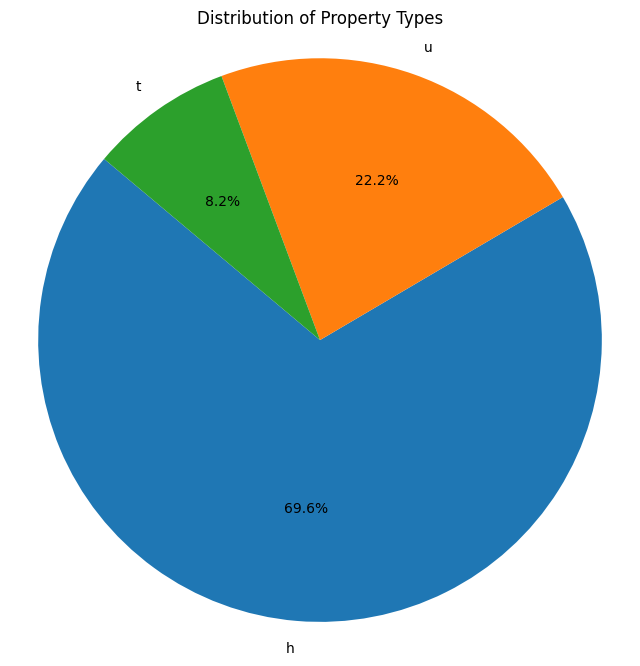

In [189]:
# pie chart of the distribution of the 'Type' column
type_counts = df['Type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Property Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()

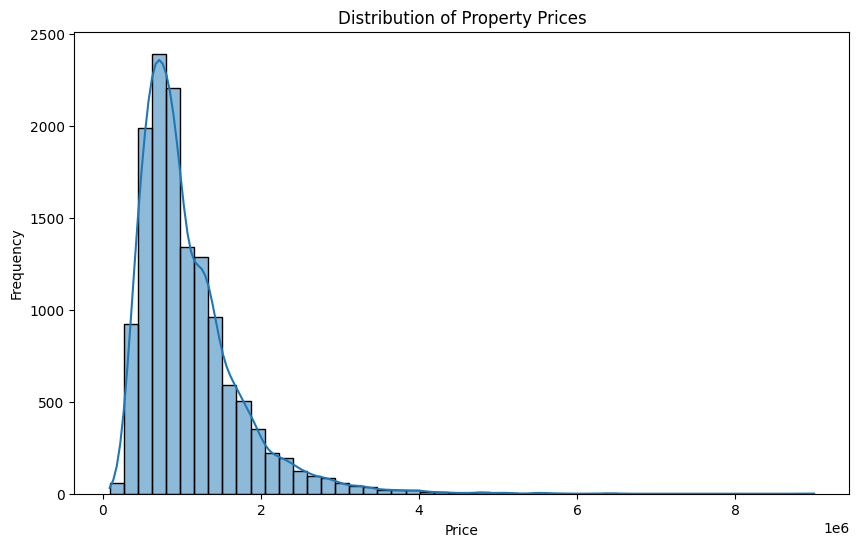

In [190]:
# Histogram of Price
plt.figure(figsize=(10, 6)) 
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Property Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

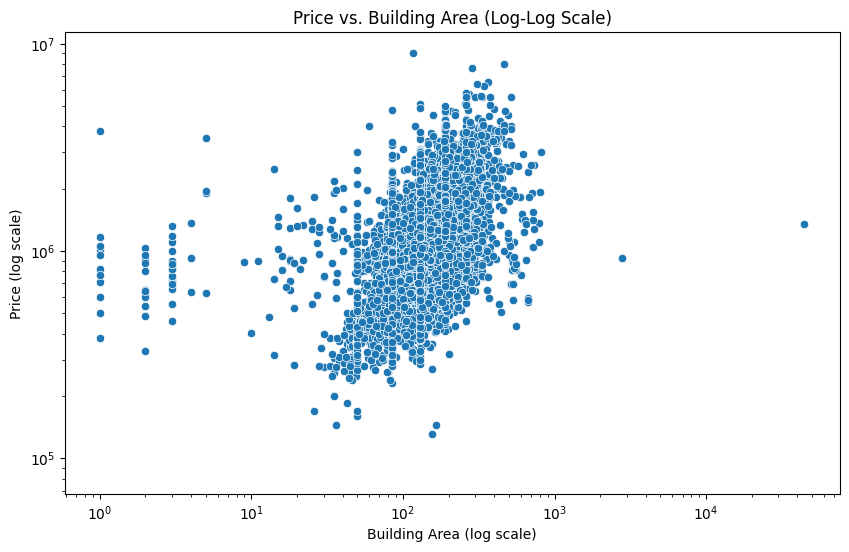

In [191]:
# Scatter plot of Price vs. Building Area
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BuildingArea', y='Price', data=df)

plt.xscale('log')
plt.yscale('log')

plt.title('Price vs. Building Area (Log-Log Scale)')
plt.xlabel('Building Area (log scale)')
plt.ylabel('Price (log scale)')
plt.show()

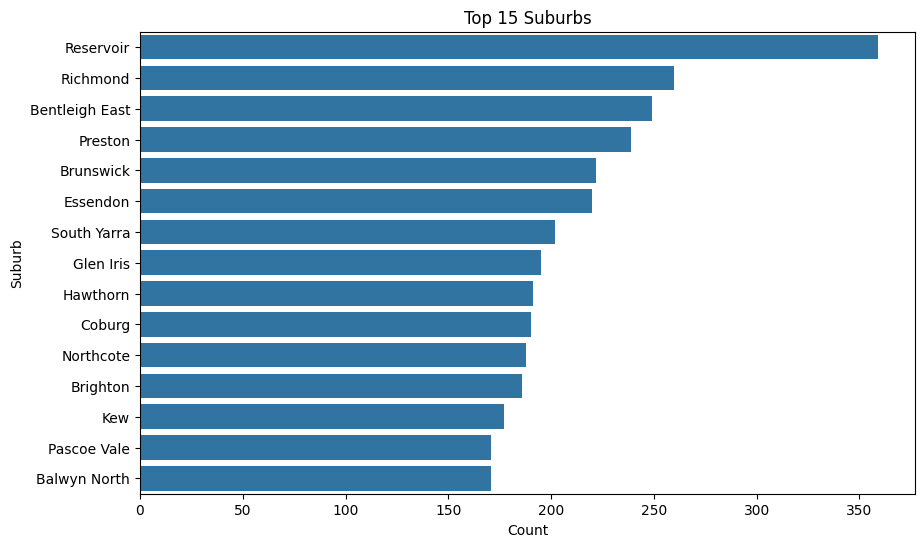

In [192]:
top_values = df['Suburb'].value_counts().nlargest(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_values.values, y=top_values.index)

plt.title('Top 15 Suburbs')
plt.xlabel('Count')
plt.ylabel('Suburb')
plt.show()

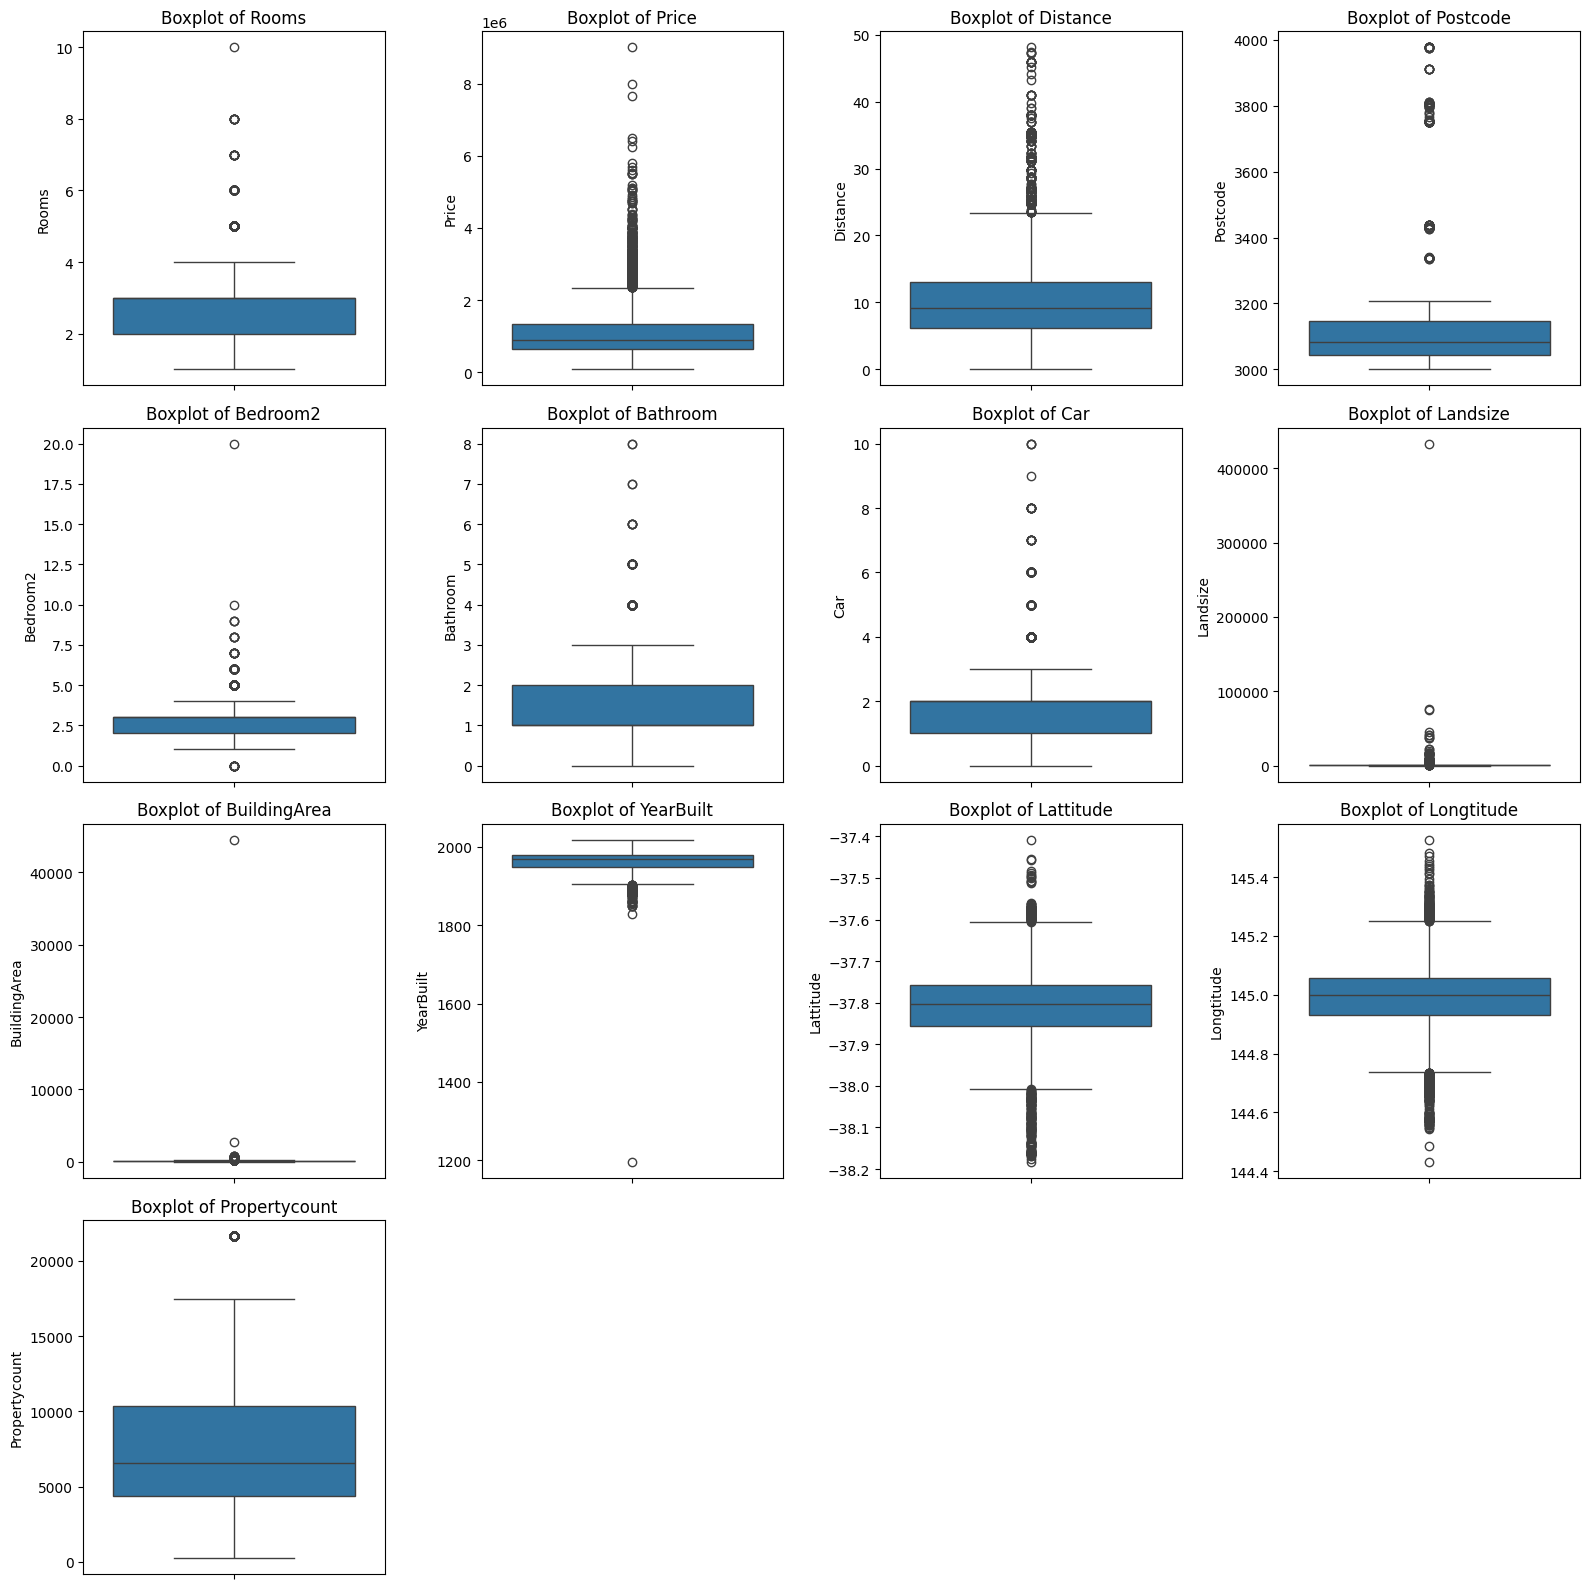

In [193]:
# Boxplots of all numeric features
numeric_df = df.select_dtypes(include=['number'])
num_cols = len(numeric_df.columns)
num_rows = (num_cols + 3) // 4
fig, axes = plt.subplots(num_rows, 4, figsize=(16, 4*num_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_df.columns):
    sns.boxplot(y=col, data=df, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Data Preprocessing

##### Outlier Detection & Correction

In [194]:
# Detect outliers using IQR method for all numeric features (excluding Price)
numeric_columns = [col for col in df.select_dtypes(include=['number']).columns]
outlier_bounds = {}

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Clip outliers to bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    

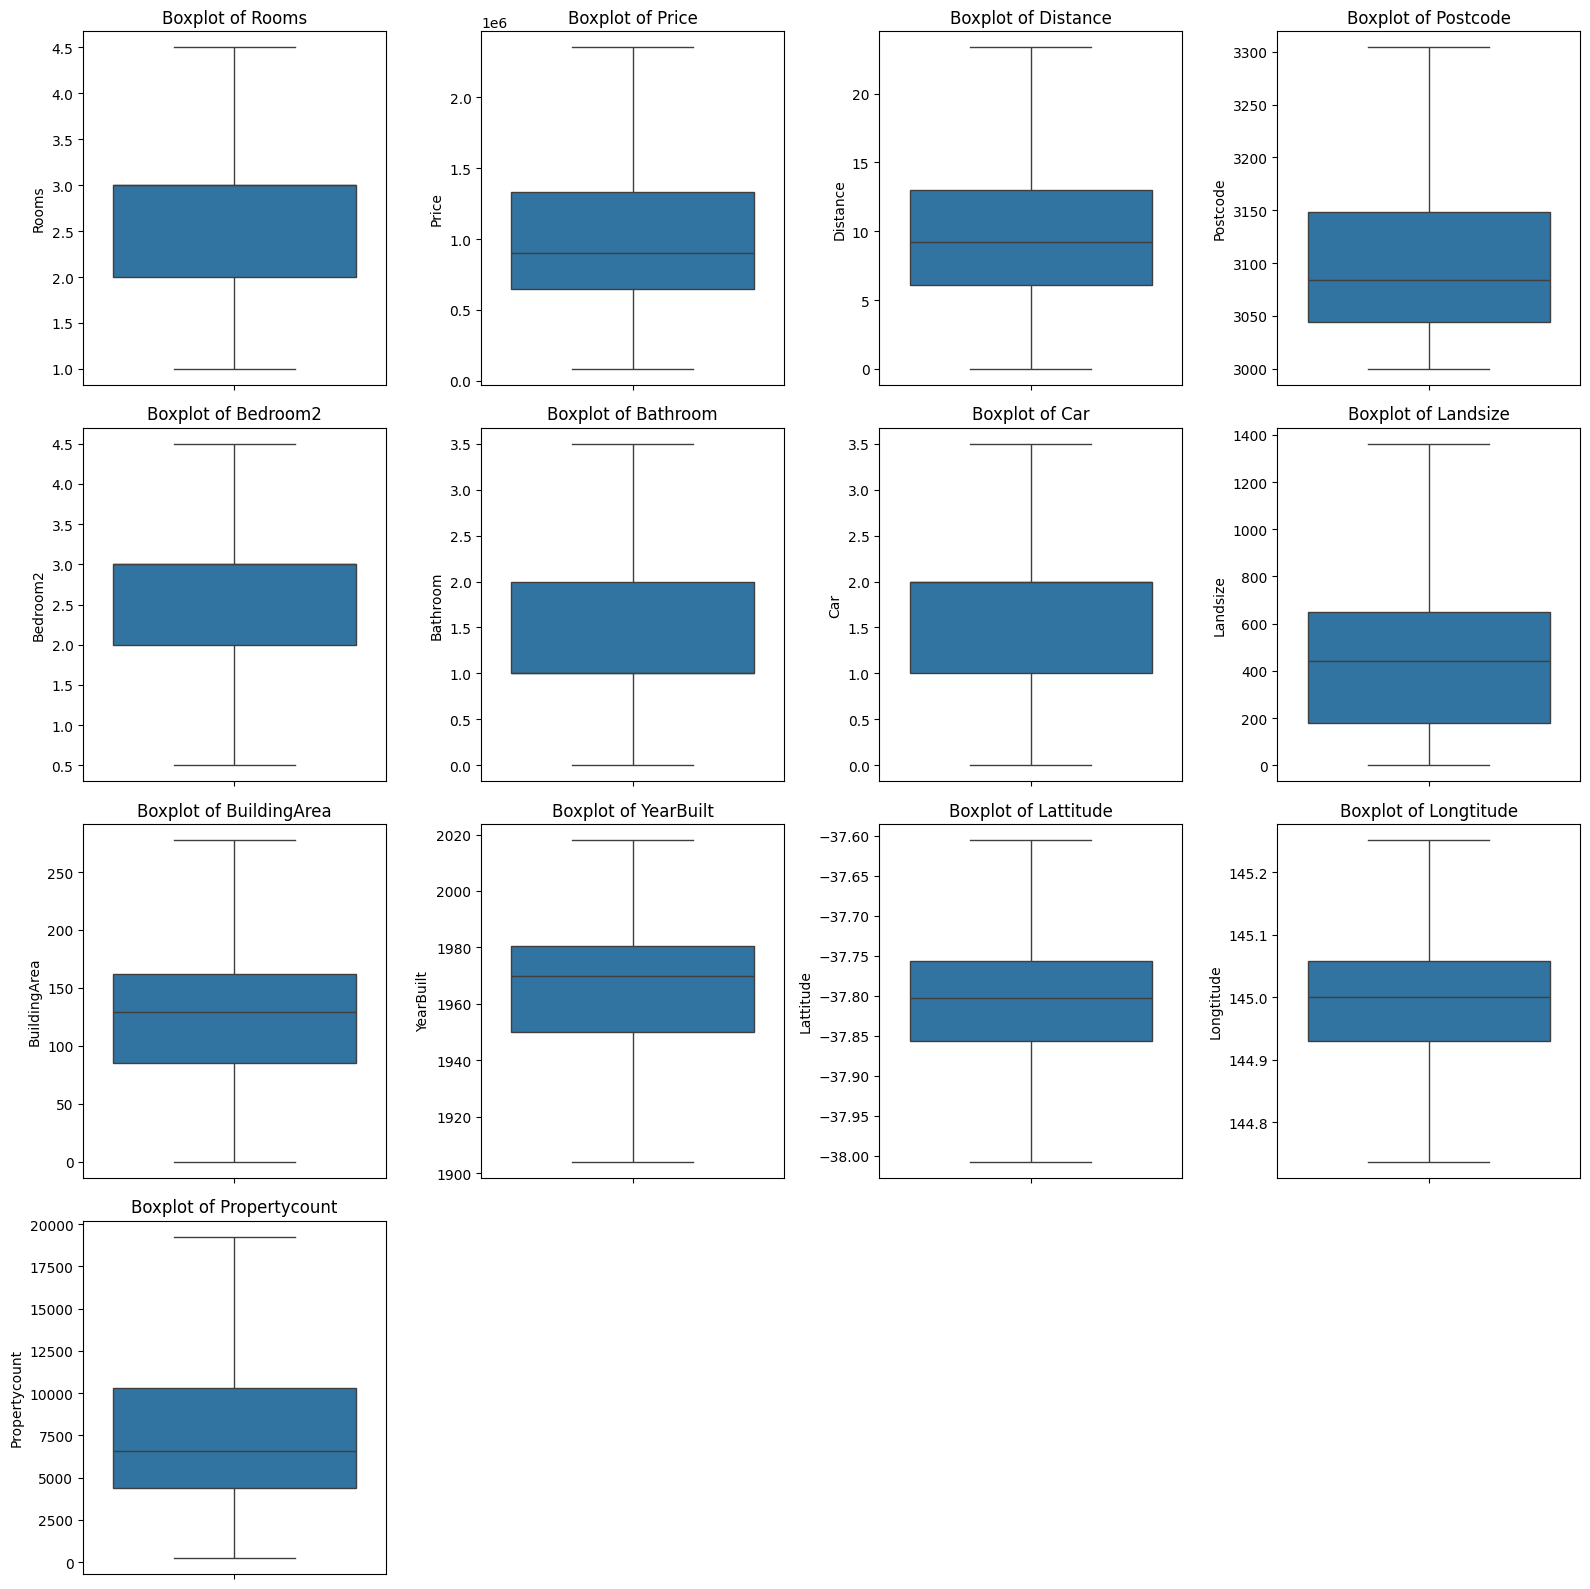

In [195]:
# Boxplots of all numeric features
numeric_df = df.select_dtypes(include=['number'])
num_cols = len(numeric_df.columns)
num_rows = (num_cols + 3) // 4  # Calculate rows needed for 4 columns per row
fig, axes = plt.subplots(num_rows, 4, figsize=(16, 4*num_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_df.columns):
    sns.boxplot(y=col, data=df, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}')

# Hide any extra subplots if columns count is not divisible by 4
for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

##### Encoding Categorical Data

In [196]:
X = df.drop("Price", axis=1)
Y = df["Price"]

# Apply LabelEncoder to categorical columns
label_encoders = {}
categorical_columns = categorical_df.columns

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Categorical columns encoded successfully!")
print(f"Encoded columns: {list(label_encoders.keys())}")

Categorical columns encoded successfully!
Encoded columns: ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']


##### Scale the data 

In [197]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Split data into train and test

In [198]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Machine Learning Models

##### XGBoost Regressor

In [199]:
model_xgb = XGBRegressor(
    n_estimators = 800 ,
    learning_rate=.05,
    max_depth=7,
    random_state=42,
    subsample=0.5,
    colsample_bytree=0.7,
    reg_alpha= 1.0,
    reg_lambda= 3.0,
    early_stopping_rounds=100
)

model_xgb.fit(
    X_train,
    Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)

Y_pred_xgb = model_xgb.predict(X_test)
Y_pred_train_xgb = model_xgb.predict(X_train)
xgb_train_rmse = root_mean_squared_error(Y_train, Y_pred_train_xgb)
print(f"XGBoost Train RMSE: {xgb_train_rmse}")

xgb_train_r2 = r2_score(Y_train, Y_pred_train_xgb)
print(f"XGBoost Train R²: {xgb_train_r2}")

XGBoost Train RMSE: 63478.97533408165
XGBoost Train R²: 0.9854933646802053


##### Checking XGBoost Regressor Accuracy

In [200]:
xgb_mse = mean_squared_error(Y_test, Y_pred_xgb)
xgb_r2 = r2_score(Y_test, Y_pred_xgb)
xgb_rmse = root_mean_squared_error(Y_test, Y_pred_xgb)
xbg_mae = mean_absolute_error(Y_test, Y_pred_xgb)
print(f"XGBoost MSE: {xgb_mse}")
print(f"XGBoost R²: {xgb_r2}")
print(f"XGBoost RMSE: {xgb_rmse}")
print(f"XGBoost MAE: {xbg_mae}")

XGBoost MSE: 34646310723.12412
XGBoost R²: 0.8753583630120951
XGBoost RMSE: 186135.1947459806
XGBoost MAE: 130638.4415328148


##### Bagging Regressor

In [201]:
model_bg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=13, min_samples_split=10, min_samples_leaf=5),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=False,
    random_state=42
)

model_bg.fit(X_train, Y_train)

Y_pred_bg = model_bg.predict(X_test)
Y_pred_train_bg = model_bg.predict(X_train)
bg_train_rmse = root_mean_squared_error(Y_train, Y_pred_train_bg)
print(f"Bagging Regressor Train RMSE: {bg_train_rmse}")
bg_train_r2 = r2_score(Y_train, Y_pred_train_bg)
print(f"Bagging Regressor Train R²: {bg_train_r2}")

Bagging Regressor Train RMSE: 159985.5286241222
Bagging Regressor Train R²: 0.9078557415913973


In [202]:
bg_mse = mean_squared_error(Y_test, Y_pred_bg)
bg_r2 = r2_score(Y_test, Y_pred_bg)
bg_train_rmse = root_mean_squared_error(Y_train, Y_pred_train_bg)
bg_mae = mean_absolute_error(Y_test, Y_pred_bg)
print(f"Bagging Regressor MSE: {bg_mse}")
print(f"Bagging Regressor R²: {bg_r2}")
print(f"Bagging Regressor RMSE: {bg_train_rmse}")
print(f"Bagging Regressor MAE: {bg_mae}")

Bagging Regressor MSE: 43005282932.22495
Bagging Regressor R²: 0.8452865903490582
Bagging Regressor RMSE: 159985.5286241222
Bagging Regressor MAE: 144941.18907851752


##### Random Forest Regressor

In [203]:
# Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, Y_train)

Y_pred_rf = rf_model.predict(X_test)
rf_train_pred = rf_model.predict(X_train)

rf_train_rmse = root_mean_squared_error(Y_train, rf_train_pred)
print(f"Random Forest Train RMSE: {rf_train_rmse}")

rf_train_r2 = r2_score(Y_train, rf_train_pred)
print(f"Random Forest Train R²: {rf_train_r2}")

Random Forest Train RMSE: 165315.127973641
Random Forest Train R²: 0.9016142788824731


##### Checking Random Forest Accuracy

In [204]:
# Checking Random Forest Regressor Accuracy

rf_mse = mean_squared_error(Y_test, Y_pred_rf)
rf_r2 = r2_score(Y_test, Y_pred_rf)
rf_rmse = root_mean_squared_error(Y_test, Y_pred_rf)
rf_mae = mean_absolute_error(Y_test, Y_pred_rf)

print(f"Random Forest MSE: {rf_mse}")
print(f"Random Forest R²: {rf_r2}")
print(f"Random Forest RMSE: {rf_rmse}")
print(f"Random Forest MAE: {rf_mae}")

Random Forest MSE: 45390710221.57625
Random Forest R²: 0.8367049100473248
Random Forest RMSE: 213050.95686613626
Random Forest MAE: 150341.63057214263


##### Decision Tree Regressor

In [205]:
# Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, Y_train)
Y_pred_dt = dt_model.predict(X_test)
dt_train_pred = dt_model.predict(X_train)
dt_train_rmse = root_mean_squared_error(Y_train, dt_train_pred)
print(f"Decision Tree Train RMSE: {dt_train_rmse}")
dt_train_r2 = r2_score(Y_train, dt_train_pred)
print(f"Decision Tree Train R²: {dt_train_r2}")

Decision Tree Train RMSE: 194878.41491974425
Decision Tree Train R²: 0.8632792742886657


##### Checking Decision Tree Regressor Accuracy

In [206]:
dt_mse = mean_squared_error(Y_test, Y_pred_dt)
dt_r2 = r2_score(Y_test, Y_pred_dt)
dt_rmse = root_mean_squared_error(Y_test, Y_pred_dt)
dt_mae = mean_absolute_error(Y_test, Y_pred_dt)
print(f"Decision Tree MSE: {dt_mse}")
print(f"Decision Tree R²: {dt_r2}")
print(f"Decision Tree RMSE: {dt_rmse}")
print(f"Decision Tree MAE: {dt_mae}")

Decision Tree MSE: 61969054353.285545
Decision Tree R²: 0.7770635829334998
Decision Tree RMSE: 248935.8438499477
Decision Tree MAE: 172924.53972064162


## Model Comparison Summary

In [207]:
# Create comparison table for all models
comparison_data = {
    'Model': ['XGBoost', 'Bagging Regressor', 'Random Forest', 'Decision Tree'],
    'Train RMSE': [xgb_train_rmse, bg_train_rmse, rf_train_rmse, dt_train_rmse],
    'Train R²': [xgb_train_r2, bg_train_r2, rf_train_r2, dt_train_r2],
    'Test MSE': [xgb_mse, bg_mse, rf_mse, dt_mse],
    'Test R²': [xgb_r2, bg_r2, rf_r2, dt_r2],
    'Test RMSE': [xgb_rmse, bg_train_rmse, rf_rmse, dt_rmse],
    'Test MAE': [xbg_mae, bg_mae, rf_mae, dt_mae]
}

comparison_df = pd.DataFrame(comparison_data)


# Format and display with better readability
st = comparison_df.style.format({
    'Train RMSE': '{:.2f}',
    'Train R²': '{:.4f}',
    'Test MSE': '{:.2f}',
    'Test R²': '{:.4f}',
    'Test RMSE': '{:.2f}',
    'Test MAE': '{:.2f}'
})

st

,Model,Train RMSE,Train R²,Test MSE,Test R²,Test RMSE,Test MAE
0,XGBoost,63478.98,0.9855,34646310723.12,0.8754,186135.19,130638.44
1,Bagging Regressor,159985.53,0.9079,43005282932.22,0.8453,159985.53,144941.19
2,Random Forest,165315.13,0.9016,45390710221.58,0.8367,213050.96,150341.63
3,Decision Tree,194878.41,0.8633,61969054353.29,0.7771,248935.84,172924.54
